In [1]:
JSON_FILE_PATH = "./json/front/A1-A3.json"

In [2]:
from src.json_pose import PoseData3D
import src.kpt_special_data as kpt_special_data
import src.draw_plot as draw_plot
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
data = PoseData3D(JSON_FILE_PATH)
json_pth = Path(JSON_FILE_PATH)
frame_idx = 0

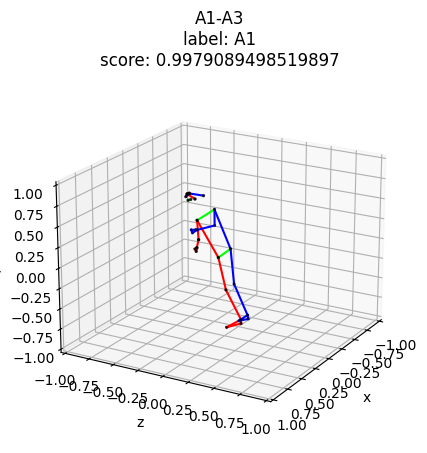

In [4]:
# 判斷影像幀是否有姿勢
assert data.get_number_of_poses(frame_idx) > 0

# 取得所需資料
left, center, right = data.get_pos_connection_list(
    frame_idx, 0, kpt_special_data.blazepose_connection, True
)

# 參數取得
pos = data.get_pos_list(frame_idx, 0, True)
label = data.get_lhc_label(frame_idx, 0)
title_name = f"""{json_pth.stem}
label: {label}
score: {data.get_kpt_score(frame_idx, 0)}"""

# 圖表設置
ax = plt.subplot(projection="3d")
ax.set_title(title_name)
ax.view_init(elev=20, azim=30, roll=0)  # 設置視角
ax = draw_plot.set_plot_data_range([-1, 1], ax) # 設置參數範圍

# 繪製表格
ax = draw_plot.get_line_plot(left, is_3d=True, color="#f00", ax=ax)
ax = draw_plot.get_line_plot(center, is_3d=True, color="#0f0", ax=ax)
ax = draw_plot.get_line_plot(right, is_3d=True, color="#00f", ax=ax)
ax = draw_plot.get_dots_in_scatter(pos, is_3d=True, dot_size=2, color="#000", ax=ax)

plt.show()